<font color = green >

## Home Task: Implement K-means algorithm

</font>


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

<font color = green >

###  Data 

</font>



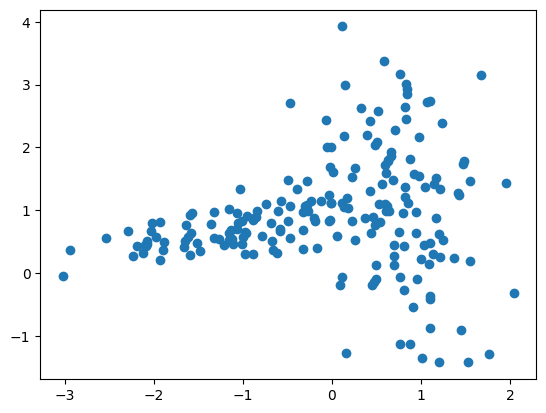

In [2]:
from sklearn.datasets import make_classification
Xc_2,_= make_classification(n_samples=200,
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0,
                                    random_state=0,
                                    n_clusters_per_class=1,
                                    class_sep = 0.8)
plt.figure()
plt.scatter  (Xc_2[:,0], Xc_2[:,1])

<font color = green >

###  Steps of implementatiion

</font>

1) Initialize $K$ centroids 

2) Assign every point to closest centroid 

3) Compute new centroids as means of samples assigned to corresponding centroid

4) Implement cost $J = \frac{1}{m}\underset{i}{\sum}(d^{(i)})^{2}$ where $d^{(i)}$ is distance from sample $x^{(i)}$ to assigned centroid $c^{(i)}$

5) Iterate setps 2,3 till cost is stabile 

6) Select the best clustering (with the least cost) from 100 results computed with random centroid  initializations 

7) Visualize results (clusters, centroids) for $K=4$

Note: 
* You may  need develop couple of additional/intermediate functions
* You may track cost changes to make sure the algorithm is working properly 

### Initializatoin centroids

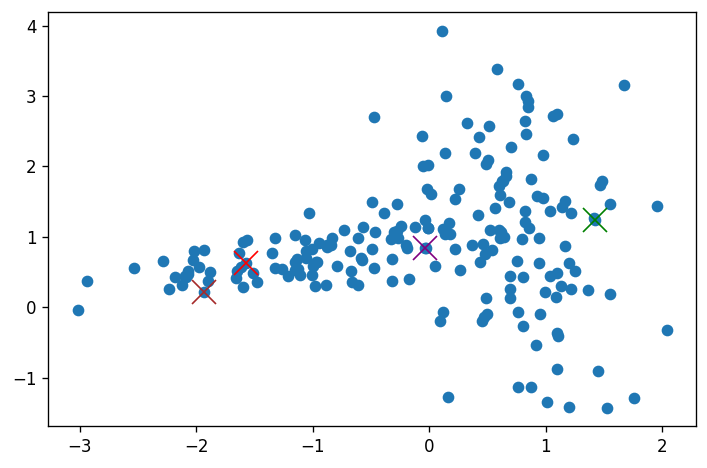

In [3]:
colors = ['red', 'brown', 'green', 'purple'] # Colors for clustering
points = np.array(list((zip(Xc_2[:, 0], Xc_2[:, 1])))) # Points in single array


def plot_points(X, y, centroids=None, closest_centroids=None):
    ''' Func for plot scatters and centroids '''

    fig, axs = plt.subplots(figsize=(6, 4), dpi=120)

    if centroids is None and closest_centroids is None:
        axs.scatter(X, y)
    elif closest_centroids is None:
        axs.scatter(X, y)
        for i, c in enumerate(centroids):
            axs.plot(c[0], c[1], marker='x', color=colors[i], markersize=14)      
    else:
        for i in range(len(X)):
            cluster_id = closest_centroids[i]
            axs.scatter(X[i], y[i], color=colors[cluster_id])
        for i, c in enumerate(centroids):
            axs.plot(c[0], c[1], marker='x', color=colors[i], markersize=20)

    fig.tight_layout()


def init_centroids(amount):
    ''' Func for init centroids '''
    return points[np.random.choice(len(points), amount)]

centroids = init_centroids(4)

plot_points(Xc_2[:, 0], Xc_2[:, 1], centroids=centroids)

### Closest distance and centroids

In [4]:
def closest_distance(samples, centroids):
    ''' Func searching closest distance from centroid to point'''
    return np.array([np.apply_along_axis(np.linalg.norm, 1, samples - c) for c in centroids])

def compute_closest_centroids(points, centroids):
    ''' Fucn computing closest centroids to points'''       
    all_distances = closest_distance(points, centroids) 
    closest_centroidsw = np.apply_along_axis(np.argmin,0,all_distances)
    return closest_centroidsw

closest_centroids = compute_closest_centroids(points, centroids)
print ('closest_centroids:\n', closest_centroids)


closest_distance(points, centroids)

closest_centroids:
 [3 3 2 2 0 0 2 0 3 2 3 2 2 3 1 1 3 2 1 2 1 2 3 3 2 3 3 3 0 2 2 0 0 0 1 2 2
 1 0 2 1 3 3 2 3 0 1 3 3 3 3 2 2 3 3 2 1 0 3 2 3 0 3 0 3 3 3 2 3 2 2 3 3 3
 0 3 3 2 2 0 3 3 0 0 3 3 3 2 2 2 0 2 3 2 0 3 3 3 3 3 3 0 2 3 0 0 0 0 3 2 0
 2 1 2 0 3 2 2 0 2 2 2 2 0 2 3 1 2 3 0 3 3 3 3 3 3 2 2 2 2 3 3 3 0 2 3 3 0
 3 1 0 3 3 3 3 0 2 0 3 2 3 0 3 3 1 2 2 2 0 0 3 2 3 3 3 1 3 3 0 3 0 2 2 3 2
 2 3 2 1 3 3 2 0 0 2 2 2 3 3 2]


array([[3.01626846, 1.37426489, 2.41842082, 2.75274093, 0.51902982,
        0.39723834, 3.38007303, 0.26050049, 0.90962761, 2.51186525,
        1.758418  , 2.71460386, 3.02236518, 1.63668266, 0.55203384,
        0.70764775, 1.86477565, 2.81957107, 0.55274483, 2.88432007,
        0.3350556 , 2.62002695, 1.75759842, 1.84239081, 2.67573463,
        2.44498506, 1.10819014, 3.45214739, 0.1367342 , 2.85976506,
        3.06309231, 0.42318673, 0.77194975, 0.68242287, 0.50857735,
        2.54094069, 3.71989324, 0.55487144, 0.78872094, 3.3190239 ,
        1.59530886, 1.19229012, 2.22492085, 3.84835008, 1.62875022,
        0.61385725, 0.63380712, 1.40098245, 3.25715775, 2.01264405,
        2.54806743, 2.96728323, 3.24151378, 0.81912992, 2.92755404,
        3.05957135, 0.52617684, 0.32484369, 2.27555607, 3.4909228 ,
        2.12637499, 0.60389533, 2.19665172, 0.89152855, 1.12542362,
        1.43287437, 0.90739818, 2.46607675, 0.99256525, 3.39919984,
        2.72872908, 1.8770784 , 0.99712911, 3.07

### Cost Func

In [5]:
def J(centroids, closest_centroids):
    ''' Func for calculation cost '''
    all_dist = []
    
    for c_index in set(closest_centroids):
        assigned_samples = points[np.where(closest_centroids == c_index)]
        all_dist_centroid = closest_distance(assigned_samples, [centroids[c_index]])
        all_dist.append(np.sum(all_dist_centroid ** 2))
    
    m = len(closest_centroids)
    return (1 / m) * np.sum(all_dist)

Cost= 1.002380226591642


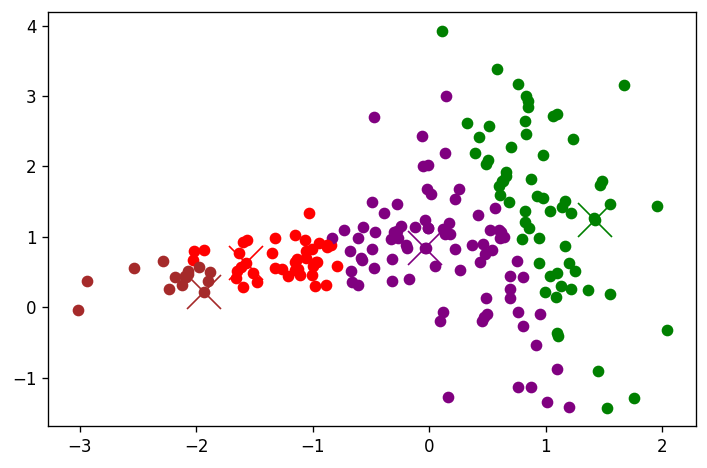

In [6]:
plot_points(Xc_2[:, 0], Xc_2[:, 1], centroids, closest_centroids)
print ('Cost= {}'.format(J(centroids, closest_centroids)))

### Compute new centroids

New centroids: [array([-1.26349875,  0.67726253]), array([-2.22277612,  0.40419592]), array([1.00650029, 1.4505698 ]), array([0.11997741, 0.75005181])]
Cost= 0.890439646623546


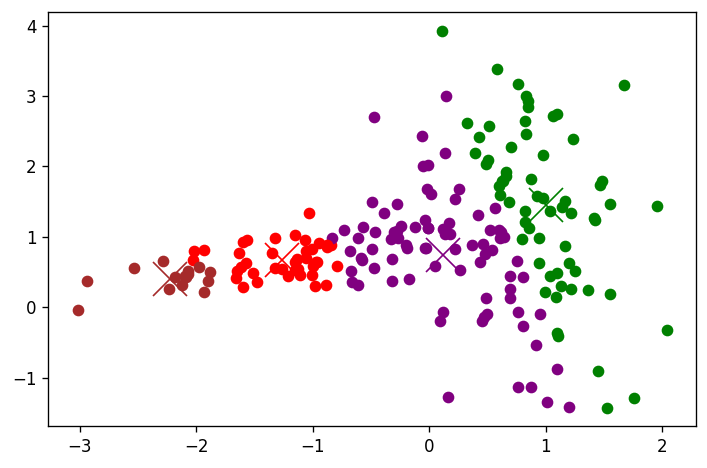

In [7]:
def compute_means(centroids, closest_centroids):      
    new_centroids= []
    for i in range (len(centroids)):
        if i not in closest_centroids: 
            new_centroids.append(centroids[i])
        else: 
            new_centroid= np.mean(points[np.where(closest_centroids==i)], axis = 0)
            new_centroids.append(new_centroid)
    return new_centroids

centroids = compute_means(centroids, closest_centroids)
print ('New centroids:',centroids)
print ('Cost= {}'.format(J(centroids, closest_centroids)))
plot_points(Xc_2[:, 0], Xc_2[:, 1], centroids=centroids, closest_centroids=closest_centroids)

### Iterate setps 2,3 till cost is stabile 

Iteration: 2 Cost: 0.8096510924636531
Iteration: 3 Cost: 0.6090149530513167
Iteration: 4 Cost: 0.5292838125900388
Iteration: 5 Cost: 0.4954288805829505
Iteration: 6 Cost: 0.4832429416856995
Iteration: 7 Cost: 0.47875482270920644
Iteration: 8 Cost: 0.47683731815014613
Iteration: 9 Cost: 0.4764213287122697


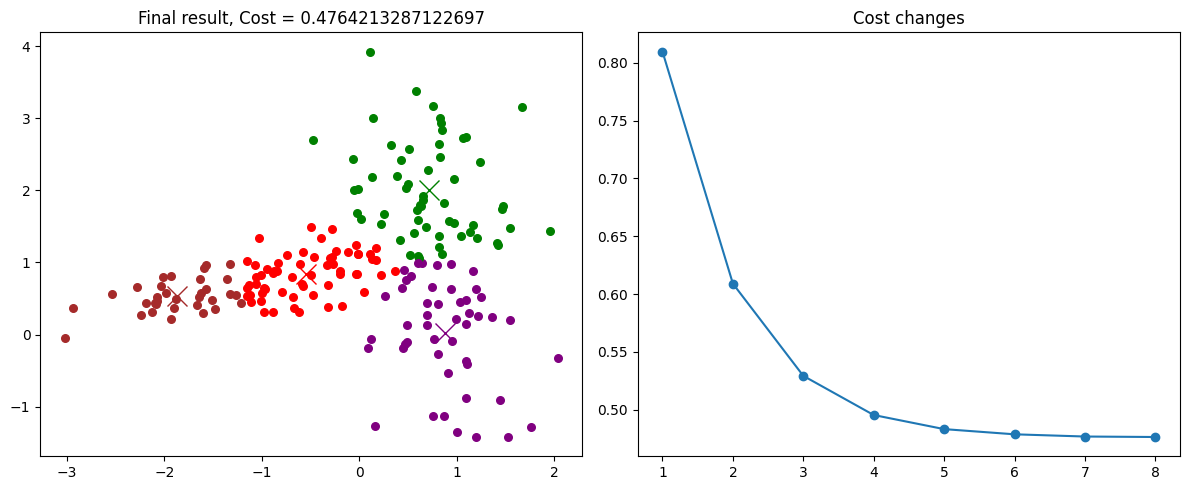

In [8]:
import numpy as np
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
cost_history = []

for iteration in range(20):
    closest_centroids = compute_closest_centroids(points, centroids)
    cost = J(centroids, closest_centroids)
    cost_history.append(cost)

    new_centroids = np.array(
        compute_means(centroids, closest_centroids),
        dtype=float
    )

    if np.allclose(new_centroids, centroids):
        break

    centroids = new_centroids

for i in range(len(points)):
    axs[0].scatter(points[i, 0], points[i, 1], color=colors[closest_centroids[i]], s=30)

for i, c in enumerate(centroids):
    axs[0].plot(c[0], c[1], marker='x', color=colors[i], markersize=14)

axs[0].set_title(f'Final result, Cost = {cost}')

axs[1].plot(range(1, len(cost_history) + 1),
            cost_history, marker='o')
axs[1].set_title('Cost changes')

for i, cost in enumerate(cost_history):
    print(f'Iteration: {i + 2} Cost: {cost}') # from 2 iter because we start code before

plt.tight_layout()
plt.show()

 #### K=4, 100 random init centroids

In [9]:
best_cost = 100
max_iters = 20

for run in range(100):
    indices = np.random.choice(len(points), size=4, replace=False)
    centroids = points[indices].copy()

    for iteration in range(max_iters):
        closest_centroids = compute_closest_centroids(points, centroids)
        new_centroids = np.array(compute_means(centroids, closest_centroids))

        if np.allclose(new_centroids, centroids):
            break

        centroids = new_centroids

    cost = J(centroids, closest_centroids)

    if cost < best_cost:
        best_cost = cost

print("Best cost:", best_cost)

Best cost: 0.4576916248652856


Text(0.5, 1.0, 'Best J in 100 random centroids is 0.4576916248652856')

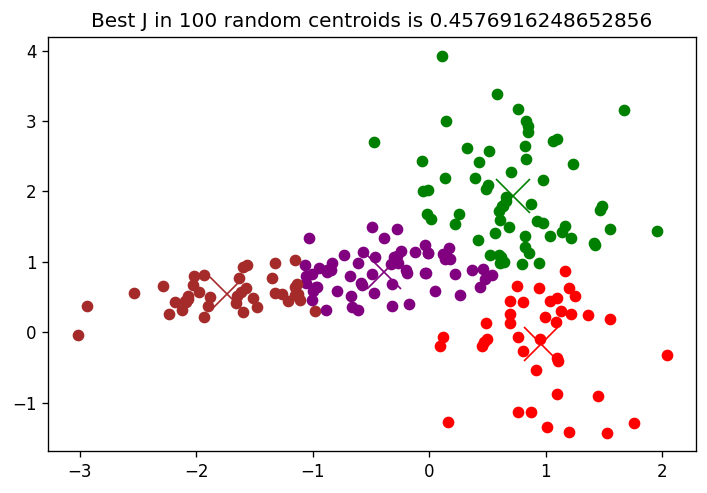

In [10]:
plot_points(Xc_2[:, 0], Xc_2[:, 1], centroids=centroids, closest_centroids=closest_centroids)
plt.title(f"Best J in 100 random centroids is {best_cost}")

### kmeans with sklearn

Text(0.5, 1.0, 'Sklearn kmeans Cost: 0.4577585400276276')

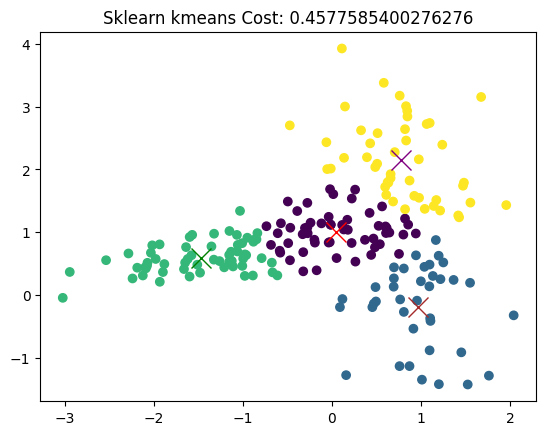

In [11]:
from sklearn.cluster import KMeans
X, y = np.array(list((zip(*points))))

clf = KMeans(n_clusters=4)
clf.fit(points)
predicted = clf.predict(points)

# Ploting scatters and centroids
plt.scatter(X, y, c=predicted)

for i, c in enumerate (clf.cluster_centers_):    
    plt.plot(c[0], c[1], marker='x', color=colors[i], markersize=14) 
    
plt.title(f'Sklearn kmeans Cost: {clf.inertia_ / len(points)}') # mean cost
